# 区间估计与不确定性

学习目标：区分标准差与标准误，推导正态均值的 z 与 t 置信区间，用重复抽样观察覆盖率，并比较解析区间和简单 bootstrap 区间的条件。

前置知识：总体参数、样本均值、方差、抽样分布、标准化、分位数；Python 函数、NumPy 数组。

运行环境：Python 3.12、NumPy 2.5、SciPy 1.18、Matplotlib 3.11；只使用本地教学数据和模拟。

环境准备：见 [README.md](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 四次读数的分散，与均值的不确定性

先用四个自制读数 9.8、10.2、10.0、10.4 mm。样本均值为 10.1 mm；偏差依次为 −0.3、0.1、−0.1、0.3 mm，平方和为 0.20 mm²。

记观测值为 $x_1,\ldots,x_n$，n 为样本数，本例 n=4。样本均值和样本标准差为

$$\bar x=\frac1n\sum_{i=1}^n x_i,\qquad
s=\sqrt{\frac1{n-1}\sum_{i=1}^n(x_i-\bar x)^2},\qquad n\ge2.$$

s 描述读数围绕样本均值的分散。若要估计“换一批独立读数，均值会变多少”，常用的是 $s/\sqrt n$。二者回答不同问题，且都与原读数同单位。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

readings = np.array([9.8, 10.2, 10.0, 10.4])
n = readings.size
mean = readings.mean()
deviations = readings - mean
sample_sd = readings.std(ddof=1)
estimated_se = sample_sd / np.sqrt(n)
print("均值（mm）：", mean)  # 预期约为 10.1。
print("偏差与平方和：", deviations, deviations @ deviations)  # 预期约为 [-0.3 0.1 -0.1 0.3] 0.2。
print("样本标准差（mm）：", sample_sd)  # 预期约为 0.258199。
print("均值标准误的估计（mm）：", estimated_se)  # 预期约为 0.129099。
print("SciPy sem 核对：", stats.sem(readings, ddof=1))  # 预期约为 0.129099。
# s≈0.2582 mm，而 s/√n≈0.1291 mm；不能用同一个词描述两者。

均值（mm）： 10.1
偏差与平方和： [-0.3  0.1 -0.1  0.3] 0.19999999999999962
样本标准差（mm）： 0.2581988897471609
均值标准误的估计（mm）： 0.12909944487358044
SciPy sem 核对： 0.12909944487358044


## 2 标准误来自估计量的抽样分布

设 $X_1,\ldots,X_n$ 独立同分布，总体均值为 $\mu\in\mathbb R$，方差为 $0<\sigma^2<\infty$。大写表示抽样前的随机量，小写表示已经得到的值。样本均值 $\bar X=n^{-1}\sum_iX_i$ 满足

$$E(\bar X)=\mu,\qquad
\operatorname{Var}(\bar X)=\frac1{n^2}\sum_{i=1}^n\operatorname{Var}(X_i)=\frac{\sigma^2}n.$$

独立性使不同观测之间的协方差项为零。估计量抽样分布的标准差叫标准误（standard error，SE）；因此 $\operatorname{SE}(\bar X)=\sigma/\sqrt n$。σ 未知时，用 $s/\sqrt n$ 估计，不是已经知道真实标准误。

样本方差 $S^2$ 的 n−1 分母使其在这些条件下满足 $E(S^2)=\sigma^2$；取平方根后的 S 并不因此成为 σ 的无偏估计。NumPy 的 std 默认 ddof=0，本章显式写 ddof=1，不能让默认分母代替统计约定。

In [2]:
sigma_for_demo = 0.3
for count in [4, 16, 64]:
    # 单次标准差保持 0.3；三个均值标准误依次为 0.15、0.075、0.0375。
    print(
        f"n={count:2d}，单次标准差={sigma_for_demo:.3f}，均值标准误={sigma_for_demo / np.sqrt(count):.4f}"
    )
print("本样本 ddof=0 与 ddof=1：", readings.std(ddof=0), sample_sd)  # 预期约为 0.223607 0.258199。
# 将独立观测数增为 4 倍，理论标准误减半；单次观测本身并未变得更稳定。

n= 4，单次标准差=0.300，均值标准误=0.1500
n=16，单次标准差=0.300，均值标准误=0.0750
n=64，单次标准差=0.300，均值标准误=0.0375
本样本 ddof=0 与 ddof=1： 0.22360679774997877 0.2581988897471609


## 3 置信区间的概率来自重复抽样

置信区间（confidence interval，CI）是一条把样本变成上下限的规则。以均值为目标，记随机上下限为 $L(X_1,\ldots,X_n)$ 和 $U(X_1,\ldots,X_n)$，简称 L、U。覆盖率是

$$P_\mu(L\le\mu\le U).$$

下标 μ 强调：计算概率时，总体参数固定，样本和区间变化。置信水平写为 $1-\alpha$，其中 $0<\alpha<1$。精确的 95% 方法在所述模型条件下覆盖率为 0.95；近似方法的实际覆盖率可能偏离这个名义水平。

得到一组具体数据后，算出的区间已固定，它要么包含固定的 μ，要么不包含。不能把它解释成“μ 在这个固定区间内的概率是 95%”，也不能解释成“95% 的单次读数落在这里”。这里针对的是总体均值，不是个体读数或新观测。

In [3]:
true_mean_demo = 10.0
candidate_intervals = np.array([[9.8, 10.2], [10.1, 10.5], [9.9, 10.4]])
contains = (candidate_intervals[:, 0] <= true_mean_demo) & (
    true_mean_demo <= candidate_intervals[:, 1]
)
print("三个示意区间是否包含固定的 10：", contains)  # 预期为 [ True False True]。
# 这些区间仅用于理解“包含”事件，未按抽样规则生成；2/3 不是某个方法的覆盖率结论。

三个示意区间是否包含固定的 10： [ True False  True]


## 4 已知总体方差时的正态均值区间

现在增加条件：$X_i$ 独立同分布于 $N(\mu,\sigma^2)$，μ 未知，σ>0 已知。这里“已知”指模型之外已给定，不能把本批数据算出的 s 当作已知 σ。

正态样本均值满足 $\bar X\sim N(\mu,\sigma^2/n)$，所以 $Z=(\bar X-\mu)/(\sigma/\sqrt n)\sim N(0,1)$。令 $z_q$ 为标准正态的 q 分位数，则对 $q=1-\alpha/2$，

$$P(-z_q\le Z\le z_q)=1-\alpha.$$

由于 $\sigma/\sqrt n>0$，将不等式整理为

$$\bar X-z_q\frac\sigma{\sqrt n}\le\mu\le\bar X+z_q\frac\sigma{\sqrt n}.$$

于是 z 区间为 $\bar x\pm z_q\sigma/\sqrt n$。正态与独立条件下这是有限样本的精确覆盖结论，不要求 n 很大。对四个读数，暂假定 σ=0.3 mm 是已知模型参数。

In [4]:
alpha = 0.05
q = 1 - alpha / 2
z_critical = stats.norm.ppf(q)
known_sigma = 0.3
z_half_width = z_critical * known_sigma / np.sqrt(n)
z_interval = mean + np.array([-1.0, 1.0]) * z_half_width
print("正态分位数：", z_critical)  # 预期约为 1.95996。
print("标准化区间的概率：", stats.norm.cdf(z_critical) - stats.norm.cdf(-z_critical))  # 预期约为 0.95。
print("已知 σ 时的 95% 均值区间（mm）：", z_interval)  # 预期约为 [ 9.80601 10.394]。
# 半宽约 0.2940 mm；区间依赖“已知 σ=0.3”的假设。

正态分位数： 1.959963984540054
标准化区间的概率： 0.95
已知 σ 时的 95% 均值区间（mm）： [ 9.8060054 10.3939946]


## 5 t 分布与自由度

若用随机的 S 代替 σ，标准化分母也在变化。Student's t 分布描述一种相关的比值分布。对正整数 ν，令 $Z,Z_1,\ldots,Z_\nu$ 相互独立且均服从 N(0,1)，定义

$$V=\sum_{j=1}^\nu Z_j^2,\qquad T=\frac Z{\sqrt{V/\nu}}.$$

V 服从 ν 个自由度的卡方分布，T 服从 ν 个自由度的 t 分布，记作 $t_\nu$。这里 ν 称为自由度（degrees of freedom，df）。t 分布关于 0 对称；有限自由度时比标准正态尾部更重，ν 增大时趋于标准正态。SciPy 也支持任意实数 df>0，本章均值区间使用整数 n−1。

为什么出现 n−1？偏差满足 $\sum_i(X_i-\bar X)=0$，n 个偏差只有 n−1 个可自由确定，最后一个由其余确定。这个线性约束解释自由度；它本身还不是 t 分布定理的证明。

In [5]:
print("四个偏差之和：", deviations.sum())  # 本次数值约为 1.8e-15。
print("由前三个偏差确定的最后一个：", -deviations[:-1].sum())  # 预期约为 0.3。
for df in [2, 4, 9, 29, 99]:
    critical = stats.t.ppf(q, df=df)
    # df 从 2 增至 99，临界值约从 4.30265 降至 1.98422，全宽从 0.86053 降至 0.39684。
    print(
        f"df={df:2d}，0.975 分位数={critical:.6f}，固定 SE=0.1 时全宽={2 * critical * 0.1:.6f}"
    )
# 此处固定标准误，只比较自由度对临界值和区间宽度的影响。

四个偏差之和： 1.7763568394002505e-15
由前三个偏差确定的最后一个： 0.29999999999999893
df= 2，0.975 分位数=4.302653，固定 SE=0.1 时全宽=0.860531
df= 4，0.975 分位数=2.776445，固定 SE=0.1 时全宽=0.555289
df= 9，0.975 分位数=2.262157，固定 SE=0.1 时全宽=0.452431
df=29，0.975 分位数=2.045230，固定 SE=0.1 时全宽=0.409046
df=99，0.975 分位数=1.984217，固定 SE=0.1 时全宽=0.396843


### 5.1 用曲线和尾概率看自由度

左图画标准化后的密度，右图画正半轴的右尾概率 P(T>t)，纵轴用对数刻度。实线代表不同自由度的 t 分布，黑色虚线为标准正态。右图更容易看出“尾部更重”，不是把密度高度直接当概率。

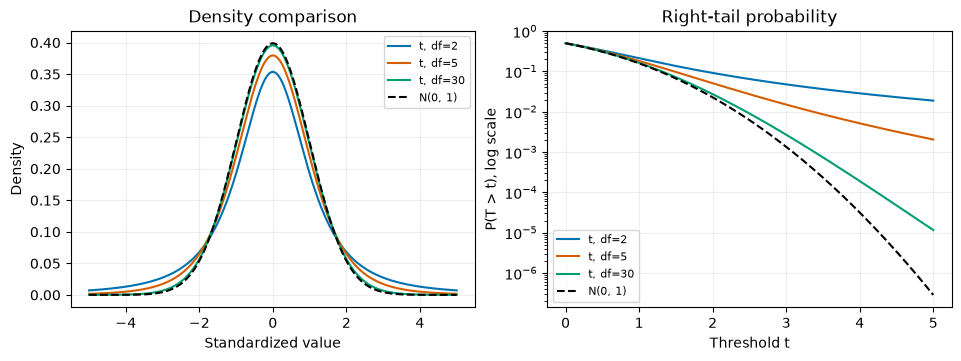

In [6]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)
colors = ["#0072B2", "#D55E00", "#009E73"]
grid = np.linspace(-5, 5, 501)
tail_grid = np.linspace(0, 5, 251)
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.5), layout="constrained")
# 固定自由度后同时画密度和右尾；右尾用对数纵轴展示小概率差异。
for df, color in zip([2, 5, 30], colors):
    axes[0].plot(grid, stats.t.pdf(grid, df=df), color=color, label=f"t, df={df}")
    axes[1].semilogy(
        tail_grid, stats.t.sf(tail_grid, df=df), color=color, label=f"t, df={df}"
    )
# 两幅图都叠加标准正态参照，以相同颜色区分各个自由度。
axes[0].plot(grid, stats.norm.pdf(grid), "k--", label="N(0, 1)")
axes[1].semilogy(tail_grid, stats.norm.sf(tail_grid), "k--", label="N(0, 1)")
axes[0].set(xlabel="Standardized value", ylabel="Density", title="Density comparison")
axes[1].set(
    xlabel="Threshold t", ylabel="P(T > t), log scale", title="Right-tail probability"
)
for ax in axes:
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
# 预期较小自由度的 t 曲线尾部更厚；右图远端高于正态右尾，df 增大时更接近正态。
plt.show()

## 6 未知总体方差时的正态均值区间

引用正态抽样定理：若 $X_1,\ldots,X_n$ 独立同分布于 $N(\mu,\sigma^2)$，n≥2、σ>0，则 $\bar X$ 与 $S^2$ 独立，且 $(n-1)S^2/\sigma^2$ 服从 $\chi^2_{n-1}$。因此

$$T=\frac{\bar X-\mu}{S/\sqrt n}\sim t_{n-1}.$$

μ 和 σ 均未知。上述分布不含这两个未知量，便可按同样的概率不等式构造区间。令 $t_{q,\nu}$ 为 $t_\nu$ 的 q 分位数，使用 ν=n−1，得到

$$\bar x\pm t_{1-\alpha/2,n-1}\frac s{\sqrt n}.$$

这里采用下侧累计概率作为分位数下标。t 区间的有限样本精确性依赖正态抽样条件；“σ 未知”本身不意味着任意数据都精确服从这个 t 统计量。

In [7]:
df = n - 1
t_critical = stats.t.ppf(q, df=df)
t_half_width = t_critical * estimated_se
t_interval = mean + np.array([-1.0, 1.0]) * t_half_width
library_interval = np.array(
    stats.t.interval(1 - alpha, df=df, loc=mean, scale=estimated_se)
)
print("df 与 t 临界值：", df, t_critical)  # 预期约为 3 3.18245。
print("未知 σ 时的 95% 均值区间（mm）：", t_interval)  # 预期约为 [ 9.68915 10.5109]。
print("直接公式与库接口的最大差：", np.max(np.abs(t_interval - library_interval)))  # 预期接近 0；本次计算为 0。
# 预期约为 [ 9.84697 10.353]。
print(
    "误用 z 临界值但保留 s 的区间：",
    mean + np.array([-1, 1]) * z_critical * estimated_se,
)
# stats.t.interval 在这里按已推导的均值区间参数使用；接口不会替我们核实抽样假设。
# 与同一个 s/√n 搭配时，t 临界值给出的区间更宽。

df 与 t 临界值： 3 3.1824463052837078
未知 σ 时的 95% 均值区间（mm）： [ 9.68914795 10.51085205]
直接公式与库接口的最大差： 0.0
误用 z 临界值但保留 s 的区间： [ 9.84696974 10.35303026]


## 7 用重复抽样观察覆盖率

设真实总体为 N(10,0.3²)，单位 mm，独立重复 R=10000 组，每组 n=8 个观测。每一组分别构造：已知 σ 的 z 区间、未知 σ 的 t 区间，以及把 s 直接塞进 z 公式的区间。真实 μ 只用于生成数据和检查覆盖，不参与区间中心计算。

记第 r 个区间覆盖 μ 的指示量为 $I_r$，覆盖时为 1，否则为 0。本次覆盖比例为 $\hat c=R^{-1}\sum_{r=1}^R I_r$。若各组独立、真实覆盖率为 c，则其模拟标准误为 $\sqrt{c(1-c)/R}$，用 $\hat c$ 替代 c 可估计本次比例的波动尺度。

名义 0.95 是理论目标，有限次比例不必恰好等于它。模拟只能观察当前生成模型，不能证明方法对所有总体都适用。

In [8]:
coverage_rng = np.random.default_rng(2007)
repetitions, group_size = 10_000, 8
true_mean, true_sd = 10.0, 0.3
# 每行是一组独立的 8 次测量；沿行求均值和标准误，共重复 10000 次。
groups = coverage_rng.normal(true_mean, true_sd, size=(repetitions, group_size))
group_means = groups.mean(axis=1)
group_se = groups.std(axis=1, ddof=1) / np.sqrt(group_size)
# 同一批样本使用三种半宽规则，便于单独比较区间构造的影响。
half_widths = {
    "已知 σ 的 z": np.full(repetitions, z_critical * true_sd / np.sqrt(group_size)),
    "未知 σ 的 t": stats.t.ppf(q, df=group_size - 1) * group_se,
    "s 直接代入 z": z_critical * group_se,
}
coverage_masks = {}
for name, half_width in half_widths.items():
    # 真实均值固定不动；布尔数组逐组记录区间是否覆盖它。
    covered = np.abs(group_means - true_mean) <= half_width
    coverage_masks[name] = covered
    proportion = covered.mean()
    mc_se = np.sqrt(proportion * (1 - proportion) / repetitions)
    # 本次三种覆盖比例约 0.9483、0.9482、0.9068；前两者在名义 0.95 附近波动。
    print(
        f"{name}：覆盖比例={proportion:.4f}，模拟标准误≈{mc_se:.4f}，平均全宽={2 * half_width.mean():.4f} mm"
    )
# 前两种规则有正态模型下的精确依据；第三种在此小样本下没有相同的精确保证。

已知 σ 的 z：覆盖比例=0.9483，模拟标准误≈0.0022，平均全宽=0.4158 mm
未知 σ 的 t：覆盖比例=0.9482，模拟标准误≈0.0022，平均全宽=0.4847 mm
s 直接代入 z：覆盖比例=0.9068，模拟标准误≈0.0029，平均全宽=0.4017 mm


### 7.1 区间在变，真实均值固定

只画前 50 组 t 区间。横轴为组编号，纵轴为均值与区间端点，单位 mm。蓝色区间包含 μ，橙色区间未包含；黑色横线始终是 10 mm。全体 10000 组的覆盖比例由上面的计数给出，不从挑选后的图估计。

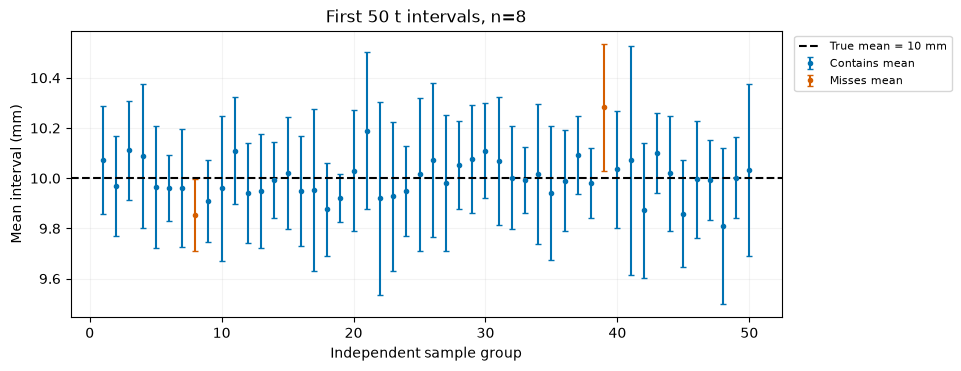

In [9]:
# 只展示前 50 次实验；覆盖率仍由前一单元的全部重复实验计算。
shown = 50
positions = np.arange(1, shown + 1)
shown_masks = coverage_masks["未知 σ 的 t"][:shown]
shown_half = half_widths["未知 σ 的 t"][:shown]
fig, ax = plt.subplots(figsize=(9.5, 3.6), layout="constrained")
# 按是否覆盖分成两组画误差线，yerr 使用半宽而不是全宽。
for mask, color, label in [
    (shown_masks, colors[0], "Contains mean"),
    (~shown_masks, colors[1], "Misses mean"),
]:
    ax.errorbar(
        positions[mask],
        group_means[:shown][mask],
        yerr=shown_half[mask],
        fmt="o",
        ms=3,
        capsize=2,
        color=color,
        label=label,
    )
ax.axhline(true_mean, color="black", linestyle="--", label="True mean = 10 mm")
ax.set(
    xlabel="Independent sample group",
    ylabel="Mean interval (mm)",
    title="First 50 t intervals, n=8",
)
ax.legend(fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.grid(alpha=0.15)
# 本次大部分线段穿过 10 mm 虚线，少数橙色线段未覆盖；50 条展示不等于全部实验覆盖率。
plt.show()

## 8 精确正态结论与大样本近似分开

若观测仍独立同分布、具有有限且正的方差，但总体不是正态，则在适当的大样本极限下，$(\bar X-\mu)/(S/\sqrt n)$ 趋于 N(0,1)。于是 $\bar x\pm z_qs/\sqrt n$ 是大样本近似区间。

有限 n 的近似误差取决于总体形状，不能仅凭“n≥30”就宣布精确。t 分位数随自由度增大接近 z 分位数，但对非正态总体，小样本 t 区间也没有上述精确覆盖保证。强偏斜、重尾或观测依赖需要额外分析；增加 n 不能自动修复错误的抽样机制。

下面从均值为 1、标准差为 1 的指数模型重新抽样，每个样本量各做 10000 组，比较 z 插入估计标准误与 t 两种规则。它们都针对总体均值 1，此处都属于有限样本近似。

In [10]:
skew_rng = np.random.default_rng(2008)
for count in [8, 40, 200]:
    skew_groups = skew_rng.exponential(scale=1.0, size=(10_000, count))
    averages = skew_groups.mean(axis=1)
    errors = skew_groups.std(axis=1, ddof=1) / np.sqrt(count)
    z_covered = np.abs(averages - 1.0) <= z_critical * errors
    t_covered = np.abs(averages - 1.0) <= stats.t.ppf(q, df=count - 1) * errors
    # 本次 n=8 的 z/t 覆盖约 0.8509/0.8918；n=200 时约 0.9490/0.9502。
    print(
        f"指数总体 n={count:3d}：z 插入式覆盖={z_covered.mean():.4f}，t 覆盖={t_covered.mean():.4f}"
    )
# 对照 0.95 看偏离；每行都是重新生成的一批有限模拟，比例有自身的模拟误差。

指数总体 n=  8：z 插入式覆盖=0.8509，t 覆盖=0.8918
指数总体 n= 40：z 插入式覆盖=0.9204，t 覆盖=0.9267
指数总体 n=200：z 插入式覆盖=0.9490，t 覆盖=0.9502


## 9 自助法从原样本的经验分布重采样

自助法（bootstrap）用可计算的重采样近似估计量的抽样变化。本章只讨论独立同分布观测的非参数 bootstrap：把每个原始观测位置分配概率 1/n，再独立、有放回地抽 n 次，得到一个与原样本同样大的重采样样本。

例如原数据为 [2,2,4,8]，单位 mm。抽到数值 2 的概率为 2/4，抽到 4、8 各为 1/4；不能先去重，再把三个不同值各分配 1/3。一次重采样允许同一个位置出现多次，也可能完全不出现。

若不放回地抽遍全部 n 个位置，只会重排原数据，均值恒定，不能观察均值的抽样波动。重采样样本也不是新采集的真实观测。

In [11]:
small_data = np.array([2.0, 2.0, 4.0, 8.0])
small_rng = np.random.default_rng(2009)
unique_values, counts = np.unique(small_data, return_counts=True)
# 给定数据的经验分布为：2 的概率 0.5，4、8 的概率各 0.25。
print("经验分布的取值与概率：", list(zip(unique_values, counts / small_data.size)))
indices = small_rng.choice(small_data.size, size=(3, small_data.size), replace=True)
resampled = small_data[indices]
print("三组抽到的原位置：\n", indices)  # 本次固定种子下为 [[3 0 1 2] [3 3 0 1] [0 1 0 0]]。
print("三组有放回重采样：\n", resampled)  # 本次固定种子下为 [[8. 2. 2. 4.] [8. 8. 2. 2.] [2. 2. 2. 2.]]。
print("每组均值：", resampled.mean(axis=1))  # 本次固定种子下为 [4. 5. 2.]。
permuted = small_rng.choice(small_data, size=small_data.size, replace=False)
print("不放回重排前后均值：", small_data.mean(), permuted.mean())  # 重排前后均值均为 4；不放回重排保留全部原值。
# 原位置的概率相等，不同数值的概率由重复次数决定。

经验分布的取值与概率： [(np.float64(2.0), np.float64(0.5)), (np.float64(4.0), np.float64(0.25)), (np.float64(8.0), np.float64(0.25))]
三组抽到的原位置：
 [[3 0 1 2]
 [3 3 0 1]
 [0 1 0 0]]
三组有放回重采样：
 [[8. 2. 2. 4.]
 [8. 8. 2. 2.]
 [2. 2. 2. 2.]]
每组均值： [4. 5. 2.]
不放回重排前后均值： 4.0 4.0


### 9.1 固定数据后，bootstrap 均值围绕什么变化

给定原数据，记重采样观测为 $X_i^*$，星号表示来自经验分布。其条件均值为 $\bar x$，条件方差为 $n^{-1}\sum_i(x_i-\bar x)^2$。因此 n 次独立重采样的均值满足

$$E_*(\bar X^*)=\bar x,\qquad
\operatorname{Var}_*(\bar X^*)=\frac1{n^2}\sum_{i=1}^n(x_i-\bar x)^2
=\frac{n-1}n\frac{s^2}n.$$

下标 * 表示固定原样本，只对重采样取期望或方差。这个公式精确描述当前经验分布；它不等于宣称已经知道真实总体的 $\sigma^2/n$。

对均值，增加重采样次数 B 只会更精细地描述当前经验分布下的变化，不会让原均值自动靠近未知 μ。固定种子、版本和调用顺序便于复现这里的有限模拟。

In [12]:
bootstrap_rng = np.random.default_rng(2010)
bootstrap_count = 10_000
resample_matrix = bootstrap_rng.choice(
    small_data, size=(bootstrap_count, small_data.size), replace=True
)
bootstrap_means = resample_matrix.mean(axis=1)
conditional_se = np.sqrt(
    np.sum((small_data - small_data.mean()) ** 2) / small_data.size**2
)
print("原均值与重采样均值的平均：", small_data.mean(), bootstrap_means.mean())  # 原样本均值为 4；本次固定种子下重采样均值的平均约为 3.99095。
print("经验分布下的解析标准误：", conditional_se)  # 预期约为 1.22474。
print("重采样均值的样本标准差：", bootstrap_means.std(ddof=1))  # 本次固定种子下约为 1.22215。
print("用原样本 s/√n 得到的标准误估计：", stats.sem(small_data))  # 给定原样本的 s/√n 约为 1.41421，不随 bootstrap 种子变化。
# 前两种标准误应在模拟波动下接近；与 s/√n 的差还包括 (n−1)/n 的有限样本因子。

原均值与重采样均值的平均： 4.0 3.99095
经验分布下的解析标准误： 1.224744871391589
重采样均值的样本标准差： 1.2221466613079524
用原样本 s/√n 得到的标准误估计： 1.4142135623730951


## 10 百分位 bootstrap 区间

对第 b 次重采样计算目标统计量 $\hat\theta_b^*$，b=1,…,B。令 $Q_q^*$ 为这些 B 个统计量的 q 分位数。百分位法（percentile method）的名义 $1-\alpha$ 区间为

$$[Q_{\alpha/2}^*,Q_{1-\alpha/2}^*].$$

本例目标是均值，统计量就是每行的重采样均值。注意取的是“均值集合”的分位数，不是原始读数的分位数。NumPy quantile 在这里明确使用 linear 插值约定。

百分位法便于看清步骤，但一般只是近似方法，小样本时区间可能过窄。它需要经验分布足以反映总体及所选统计量的抽样变化；没有指定一个正态分布族，不代表完全没有假设。四点数据只用于教学演示，不能靠 B=10000 就给它增加真实信息。

In [13]:
percentiles = np.array([alpha / 2, 1 - alpha / 2])
small_bootstrap_interval = np.quantile(bootstrap_means, percentiles, method="linear")
raw_data_interval = np.quantile(small_data, percentiles, method="linear")
print("均值的百分位 bootstrap 区间（mm）：", small_bootstrap_interval)  # 本次固定种子下约为 [2. 6.5]。
print("直接取原数据分位数（不同对象，mm）：", raw_data_interval)  # 给定原数据的分位数区间为 [2, 7.7] mm；这是原值的区间。
# 第二行是原始经验分布的位置范围，不能当作同一个均值区间。

均值的百分位 bootstrap 区间（mm）： [2.  6.5]
直接取原数据分位数（不同对象，mm）： [2.  7.7]


### 10.1 用 SciPy 核对同一方法

stats.bootstrap 的 data 是样本序列，只有一组数据时也写成单元素元组 (small_data,)。statistic=np.mean 指定统计量；n_resamples 指定 B；rng 接收局部 Generator。

这里显式指定 method="percentile"。SciPy 的默认方法是 BCa，它还校正偏差和加速度，不与本节简单百分位公式混用。返回值中的 bootstrap_distribution 是重采样统计量，standard_error 是它们的样本标准差。

In [14]:
# 显式选择 percentile 方法，并从 SciPy 保留的同一批重采样统计量核对端点。
small_result = stats.bootstrap(
    (small_data,),
    np.mean,
    confidence_level=1 - alpha,
    n_resamples=10_000,
    method="percentile",
    rng=np.random.default_rng(2011),
)
# 分位数对应区间两端；使用相同统计量避免把随机样本差异混入方法比较。
manual_interval = np.quantile(
    small_result.bootstrap_distribution, percentiles, method="linear"
)
print("SciPy 区间：", small_result.confidence_interval)  # 本次固定种子下约为 ConfidenceInterval(low=2, high=6.5)。
print("从同一批重采样统计量取分位数：", manual_interval)  # 本次固定种子下约为 [2. 6.5]。
# 预期接近 0；本次计算为 0。
print(
    "区间端点最大差：",
    np.max(
        np.abs(np.array(small_result.confidence_interval) - manual_interval)
    ),
)
# bootstrap 均值的样本标准差估计标准误，不是原始观测的标准差。
# 本次固定种子下约为 1.2234 1.2234。
print(
    "返回的 SE 与重新计算的标准差：",
    small_result.standard_error,
    small_result.bootstrap_distribution.std(ddof=1),
)
# 此处核对的是同一批重采样结果；不同种子生成的两批结果不要求逐项相等。

SciPy 区间： ConfidenceInterval(low=np.float64(2.0), high=np.float64(6.5))
从同一批重采样统计量取分位数： [2.  6.5]
区间端点最大差： 0.0
返回的 SE 与重新计算的标准差： 1.223396366623257 1.223396366623257


## 11 重采样不能修复错误的观测单位

普通逐点 bootstrap 以观测之间独立同分布为前提。若多个数来自同一个对象或相邻时间，逐点抽取可能破坏原有依赖；应先明确独立的采样单位及机制，再选择匹配的重采样方法。

把每个读数复制五遍，不会增加独立信息。若把复制后的长度误当 n，$s/\sqrt n$ 会变小，构造的区间就可能给出虚假的精确感。

另外，极端值等统计量也不能机械套普通 bootstrap。例如从连续均匀总体 Uniform(0,θ) 估计上端点 θ，任一逐点重采样的最大值都不超过原样本最大值；简单百分位区间的上端因此无法越过它。这揭示了方法与目标量不匹配的边界，不是增加 B 可以解决的问题。

In [15]:
duplicated = np.repeat(readings, 5)
print("原始个数与复制后行数：", readings.size, duplicated.size)  # 预期为 4 20。
print("两个均值：", readings.mean(), duplicated.mean())  # 复制前后的均值均为 10.1，复制没有改变数值的比例。
print("原始 SE 与错误地按行数计算的 SE：", stats.sem(readings), stats.sem(duplicated))  # 原始 SE 约为 0.129099；机械按复制后行数计算会降为约 0.0512989。
endpoint_data = np.array([0.15, 0.32, 0.55, 0.87])
endpoint_rng = np.random.default_rng(2012)
endpoint_resamples = endpoint_rng.choice(
    endpoint_data, size=(2000, endpoint_data.size), replace=True
)
endpoint_maxima = endpoint_resamples.max(axis=1)
print("原最大值与重采样最大值的最大值：", endpoint_data.max(), endpoint_maxima.max())  # 本次重采样最大值的最大值为 0.87，与原最大值相同；重采样不会产生更大的新数值。
print("最大值的简单百分位区间：", np.quantile(endpoint_maxima, percentiles))  # 本次固定种子下约为 [0.32 0.87]。
# 若模型的真实端点为 1，以上区间无法包含它；这里的输入用于机制反例。

原始个数与复制后行数： 4 20
两个均值： 10.1 10.1
原始 SE 与错误地按行数计算的 SE： 0.12909944487358044 0.05129891760425766
原最大值与重采样最大值的最大值： 0.87 0.87
最大值的简单百分位区间： [0.32 0.87]


## 12 综合应用：同一批测量的两种均值区间

独立模拟 n=40 个 N(10,0.3²) 的读数，单位 mm。把它们当作待分析数据时，均值和方差都未知；真实 10 与 0.3 仅用于生成与事后核对。用 t 公式构造 95% 均值区间，再用 B=9999 次百分位 bootstrap 构造另一区间。

t 方法有本例正态模型下的精确覆盖依据；百分位方法用经验分布近似。比较中心、宽度和一次是否包含真实值，不能据此断言哪种方法普遍更可靠，更不能只挑较窄的区间汇报。

In [16]:
# 先生成一份 40 个观测的模拟样本，两种区间方法都基于这同一份数据。
measurement_rng = np.random.default_rng(2013)
measurements = measurement_rng.normal(loc=10.0, scale=0.3, size=40)
measurement_mean = measurements.mean()
measurement_se = stats.sem(measurements)
# t 区间用样本标准误和 n-1 个自由度计算均值的不确定性。
measurement_t = np.array(
    stats.t.interval(
        0.95, df=measurements.size - 1, loc=measurement_mean, scale=measurement_se
    )
)
# 另一个固定种子只控制有放回重采样，不重新生成观测数据。
measurement_bootstrap = stats.bootstrap(
    (measurements,),
    np.mean,
    confidence_level=0.95,
    n_resamples=9999,
    method="percentile",
    rng=np.random.default_rng(2014),
)
measurement_percentile = np.array(measurement_bootstrap.confidence_interval)
# 样本量固定为 40；本次模拟均值约 9.99974 mm，样本标准差约 0.249176 mm。
print(
    "样本量、均值、样本标准差：",
    measurements.size,
    measurement_mean,
    measurements.std(ddof=1),
)
# 本次数据的解析 SE 估计约 0.0393982 mm，bootstrap 估计约 0.0389482 mm。
print(
    "解析 SE 估计与 bootstrap SE 估计：",
    measurement_se,
    measurement_bootstrap.standard_error,
)
# 比较端点、全宽和本次覆盖情况；一次实验不能验证长期覆盖率。
for name, interval in [
    ("t", measurement_t),
    ("percentile bootstrap", measurement_percentile),
]:
    # 本次 t/bootstrap 区间约 [9.92005, 10.07943]/[9.92316, 10.07657] mm，均包含生成均值 10 mm。
    print(
        f"{name}：区间={interval} mm，全宽={np.diff(interval)[0]:.6f} mm，包含生成均值={interval[0] <= 10 <= interval[1]}"
    )
# 本次区间及是否覆盖是真实计算结果；一次包含或遗漏均不能验证 95% 的长期覆盖率。

样本量、均值、样本标准差： 40 9.999743820164367 0.24917641030085497
解析 SE 估计与 bootstrap SE 估计： 0.03939824978676718 0.03894816163428349
t：区间=[ 9.92005334 10.0794343 ] mm，全宽=0.159381 mm，包含生成均值=True
percentile bootstrap：区间=[ 9.92315862 10.07656689] mm，全宽=0.153408 mm，包含生成均值=True


### 12.1 图中明确区分统计量分布与区间

左图是固定这 40 个数据后的 bootstrap 均值分布，蓝虚线是原样本均值，黑虚线是生成模型的真实均值。它围绕原样本均值变化，不是参数 μ 的后验概率分布。

右图用横线画两种均值区间，圆点是共同的点估计。区间端点直接来自计算，不把 s、SE 或覆盖率当成同一种误差条。

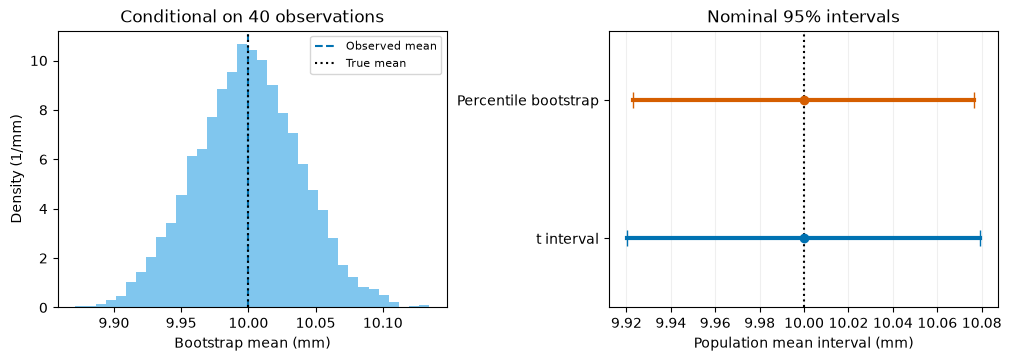

In [17]:
# 左图画重采样均值的分布，右图画总体均值区间，两者横轴含义不同。
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), layout="constrained")
axes[0].hist(
    measurement_bootstrap.bootstrap_distribution,
    bins=35,
    density=True,
    color="#56B4E9",
    alpha=0.75,
)
axes[0].axvline(
    measurement_mean, color=colors[0], linestyle="--", label="Observed mean"
)
axes[0].axvline(10.0, color="black", linestyle=":", label="True mean")
axes[0].set(
    xlabel="Bootstrap mean (mm)",
    ylabel="Density (1/mm)",
    title="Conditional on 40 observations",
)
axes[0].legend(fontsize=8)
# 每条线段端点直接来自区间结果；中间圆点标记同一个观测均值。
for position, interval, color in [
    (0, measurement_t, colors[0]),
    (1, measurement_percentile, colors[1]),
]:
    axes[1].plot(interval, [position, position], color=color, linewidth=3)
    axes[1].plot(interval, [position, position], "|", color=color, markersize=12)
    axes[1].scatter([measurement_mean], [position], color=color, zorder=3)
axes[1].axvline(10.0, color="black", linestyle=":")
axes[1].set(
    yticks=[0, 1],
    yticklabels=["t interval", "Percentile bootstrap"],
    ylim=(-0.5, 1.5),
    xlabel="Population mean interval (mm)",
    title="Nominal 95% intervals",
)
axes[1].grid(axis="x", alpha=0.2)
# 本次重采样均值分布集中在 10 mm 附近；右侧两个区间高度重叠，bootstrap 区间略窄。
plt.show()

## 本章小结

（1）标准差描述观测的分散，标准误描述估计量的抽样变化。σ/√n 是独立同分布均值的真实标准误，s/√n 是相应估计。

（2）置信水平描述区间规则的重复抽样覆盖表现。固定数据后的区间不赋予固定参数一个概率，也不是单次读数的范围。

（3）独立正态观测下，已知 σ 使用 z 区间，未知 σ 使用自由度 n−1 的 t 区间。非正态的大样本结论是近似，不能省略抽样与矩条件。

（4）普通 bootstrap 从原样本有放回地抽取同样数量的观测，用统计量的重采样变化构造近似区间。增加重采样次数不能替代增加真实样本，也不能修复依赖、代表性不足或不适合的目标统计量。

自查：为什么四个偏差只有三个可自由确定？为什么同一批数据的 s 与 s/√n 不同？为什么把 B 翻倍不等于把真实样本数翻倍？

## 练习

（1）对 [4.7,5.0,5.2,4.9,5.1] mm，分别计算“已知 σ=0.2 mm 的 90% z 区间”和“σ 未知的 90% t 区间”。先列参数、自由度和分位数，再核对手算与 SciPy。解释为什么两种计算采用了不同信息条件。

In [18]:
exercise_readings = np.array([4.7, 5.0, 5.2, 4.9, 5.1])
exercise_confidence = 0.90
# 补充：均值、s、SE、两种临界值与区间，并写清各自模型假设。

（2）从 N(2,1) 独立抽 5000 组、每组 6 个样本。比较 90%、95%、99% t 区间的覆盖比例和平均宽度。是否每次实验都恰有相应百分比覆盖？提高置信水平而保持数据不变，会怎样影响区间？

In [19]:
exercise_rng = np.random.default_rng(2015)
exercise_groups = exercise_rng.normal(2.0, 1.0, size=(5000, 6))
# 补充：同一组数据的不同置信水平区间；覆盖用固定真实均值 2 判断。

（3）对综合测量数据，使用四个不同种子，各计算 B=300 与 B=10000 的百分位 bootstrap 区间，比较端点波动。原始 n 保持 40。解释这里减小了哪一层模拟误差，为什么不能据此宣称真实均值估计误差已经减少。

In [20]:
exercise_seeds = [10, 20, 30, 40]
exercise_bootstrap_counts = [300, 10_000]
# 补充：固定 measurements，按种子与 B 重采样；不要每次又生成新原始样本。

（4）设先独立生成 8 个对象的读数，每个对象的同一个数被原样复制 5 次，形成 40 行。比较把 40 行错误当独立观测得到的 t 区间，与只使用 8 个独立对象得到的区间。说明普通逐行 bootstrap 为什么也不能自动修复这个问题，并指出应该保留的观测单位。

In [21]:
object_rng = np.random.default_rng(2016)
object_readings = object_rng.normal(10.0, 0.3, size=8)
recorded_rows = np.repeat(object_readings, 5)
# 补充：两套区间、自由度与标准误；不要把复制次数计入独立样本量。

## 练习提示与解析

以下对应练习（3）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：本题固定原始 40 个测量值，只改变从它们重采样的次数。

提示 2：区分原始抽样的不确定性与用有限次重采样近似分位数的误差。

### 练习（3）参考解析

每个 bootstrap 样本仍含 40 次有放回抽取。B 从 300 增至 10000，只让经验分布下的重采样均值分位数估计通常更稳定；没有获得新的独立测量，也没有改变原始样本均值。

四个种子给出的区间端点一般不会完全相同。应比较各 B 下端点的范围，并保留实际输出，不能预填“每个种子的区间都更窄”或“每次端点变化都更小”。增加 B 减少的是重采样的蒙特卡洛误差，不保证覆盖率更接近名义水平，也不能修复原数据的偏差或依赖问题。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| MIT OpenCourseWare | Jeremy Orloff、Jonathan Bloom，18.05 Spring 2022：[Reading 23a](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class23-prep-a.pdf)，§3.1–3.2、第 2–3 页，正态总体 z/t 区间的标准化推导；[Reading 23b](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class23-prep-b.pdf)，§4、第 3–5 页，有限方差下的大样本近似与偏斜总体覆盖实验；[Reading 24](https://ocw.mit.edu/courses/18-05-introduction-to-probability-and-statistics-spring-2022/mit18_05_s22_class24-prep.pdf)，§4–7、第 2–6 页，经验分布、同样大小的有放回重采样与百分位法；§8、第 7 页，重采样中心与原均值的关系。 |
| NIST/SEMATECH | [§7.1.4 What are confidence intervals?](https://www.itl.nist.gov/div898/handbook/prc/section1/prc14.htm)，固定参数与随机区间、已知 σ 的例子；[§1.3.5.2 Confidence Limits for the Mean](https://www.itl.nist.gov/div898/handbook/eda/section3/eda352.htm)，覆盖解释、t 区间及样本量/标准差对宽度的影响；[§1.3.6.6.4 t Distribution](https://www.itl.nist.gov/div898/handbook/eda/section3/eda3664.htm)，对称性、尾部与自由度趋大行为。 |
| Purdue University | Bruce A. Craig，[Statistical Concepts](https://www.stat.purdue.edu/~bacraig/notes1/topic2.pdf)，PDF 第 2 页、讲义 2-3–2-5：样本均值方差、样本方差无偏性与自由度；PDF 第 3 页、讲义 2-7–2-8：独立正态平方和、t 比值定义、正态样本均值与方差独立。 |
| University of Minnesota | Nathaniel E. Helwig，[Nonparametric Bootstrap in R](https://users.stat.umn.edu/~helwig/notes/npboot-notes.html)，2021-01-04，§2.1–2.4：i.i.d. 条件、经验分布、插入式矩估计及小样本限制；§3.1：标准误的重采样估计；§5.3 Percentile：百分位区间及小样本偏窄的边界。 |
| Carnegie Mellon University | Cosma Shalizi，[The Bootstrap](https://www.stat.cmu.edu/~cshalizi/uADA/15/lectures/06.pdf)，2015 讲义，§6.5–6.6、正文第 143–144 页（PDF 第 24–25 页）：观测之间有依赖时逐点重采样会破坏结构，极端值统计量的失效例子。 |
| SciPy 官方文档 | SciPy 1.18：[sem](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.sem.html)，ddof=1、至少两个观测；[t](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html)，df>0、pdf/sf/ppf/interval 和 loc/scale；[bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html)，percentile 步骤、data/statistic/n_resamples/rng、默认 BCa 及返回的 bootstrap_distribution/standard_error。 |
| NumPy 官方文档 | NumPy 2.5：[std](https://numpy.org/doc/stable/reference/generated/numpy.std.html)，Notes 中 ddof、Bessel 校正及 S 仍有偏；[Generator.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html)，replace、size 和等概率位置采样；[quantile](https://numpy.org/doc/stable/reference/generated/numpy.quantile.html)，linear 插值分位数；[Random Generator](https://numpy.org/doc/stable/reference/random/generator.html)，局部生成器与版本复现条件。 |
| Matplotlib 官方文档 | Matplotlib 3.11：[Axes.errorbar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.errorbar.html)，yerr 为相对中心的误差长度；[Axes.hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html)，density 的柱形面积归一化；[Axes.semilogy](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.semilogy.html)，对数纵轴。 |